# Chapter 3: Geometry over Fields

Source orientation: printed pages 117-164; PDF pages 129-176. Sections 13-18: the real Cartesian plane, abstract fields and incidence, ordered fields and betweenness, congruence of segments and angles, rigid motions and SAS, and non-Archimedean geometry.

**Chapter question.** How much algebra must a field carry before the coordinate plane `F^2` behaves like the Hilbert and Euclidean planes studied earlier?

The chapter's main move is a translation move. Instead of accepting point, line, between, and congruent as primitive words, we build them from coordinates. Then we watch which algebraic features are needed for each geometric axiom family. Any field gives points, lines, incidence, and parallels. An ordered field gives betweenness. A Pythagorean ordered field supports the segment-transfer and rigid-motion story. A Euclidean field gives circle intersections. Non-Archimedean ordered fields show that even very reasonable coordinate planes can violate the Archimedean intuition that repeated unit lengths eventually pass every length.

This notebook is an original standalone teaching version of the assigned span. It uses the source only for structure, terminology, theorem route, and model choices; it does not copy textbook prose, figures, exercises, screenshots, or page crops.


## Computational translation guide

| Book notion | Computational model in this notebook | What to inspect |
| --- | --- | --- |
| Field `F` | A set with addition, multiplication, inverses, and `0 != 1`; finite prime fields use arithmetic modulo `p` | Which operations are enough to solve line equations? |
| Point | A pair `(x, y)` in `F^2` | Every geometric object is encoded by field data |
| Line | A solution set of `a*x + b*y + c = 0`, with `(a, b) != (0, 0)` | Linear equations replace ruler-drawn lines |
| Parallel lines | Equal slope, including a special vertical slope | Parallelism is already algebraic over any field |
| Betweenness | A collinear point has parameter `0 < lambda < 1` in an ordered field | Order is extra structure, not a field axiom |
| Segment congruence | Equality of squared distances `(dx)^2 + (dy)^2` | Square roots are avoided until we need to lay off actual lengths |
| Angle congruence | Equality of the tangent computed from slopes | Slopes remember lines; rays require order and side choices |
| Rigid motion | A bijection preserving lines, betweenness, segment congruence, and angle congruence | Translations, rotations, and reflections make superposition legitimate |
| Non-Archimedean field | Rational functions ordered by eventual sign as `t` becomes large | `t` is bigger than every integer, while `1/t` is infinitesimal |

The computational checks near the end turn these translations into invariants: incidence counts in finite fields, Pasch-style crossing logic for betweenness, exact symbolic checks for square-root gates, distance preservation for rigid motions, and eventual-order comparisons for a non-Archimedean toy model.


## Route through the chapter

1. **Coordinate planes over fields.** Build points and lines in `F^2`, then test incidence and parallelism in `GF(2)` and `GF(5)`.
2. **Order and betweenness.** Show why a field alone cannot know which point lies between two others, and test a Pasch-style crossing in an ordered field.
3. **Congruence gates.** Use distance squared and tangent of slopes to separate easy congruence checks from the square-root properties needed for laying off segments and intersecting circles.
4. **Rigid motions and SAS.** Treat Euclid's superposition as a theorem about enough transformations, then verify translation/rotation/reflection invariants numerically.
5. **Finite and non-Archimedean toy models.** Use finite fields to show incidence without order, and rational functions ordered at infinity to show an ordered geometry where `t` outruns every integer.
6. **Applied lab.** Audit several fields by asking which geometric axiom families their algebra can support.


In [1]:
from __future__ import annotations

from itertools import combinations
from pathlib import Path
import math
import sys

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import sympy as sp


def find_book_root() -> Path:
    start = Path.cwd().resolve()
    for base in [start, *start.parents]:
        for candidate in (base, base / "Euclid-and-Beyond"):
            if (candidate / "00-book-index.ipynb").exists() and (candidate / "utils").exists():
                return candidate
    raise RuntimeError("Could not find the Euclid-and-Beyond book root")


BOOK_ROOT = find_book_root()
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import assert_artifact, display_artifact, save_json, save_matplotlib, save_plotly_html
from utils.plotting import PALETTE, draw_segment, label_point, set_equal_axes

UNIT = "chapter-03"
ARTIFACT_ROOT = BOOK_ROOT / "artifacts"
CHAPTER_DIR = BOOK_ROOT / "chapter-03-geometry-over-fields"
NOTEBOOK_PATH = CHAPTER_DIR / "03-geometry-over-fields.ipynb"
FIG_DIR = ARTIFACT_ROOT / UNIT / "figures"
HTML_DIR = ARTIFACT_ROOT / UNIT / "interactive"
CHECK_DIR = ARTIFACT_ROOT / UNIT / "checks"
TABLE_DIR = ARTIFACT_ROOT / UNIT / "tables"
for directory in (FIG_DIR, HTML_DIR, CHECK_DIR, TABLE_DIR):
    directory.mkdir(parents=True, exist_ok=True)

SOURCE_SPAN = {
    "book": "Geometry: Euclid and Beyond",
    "chapter": 3,
    "chapter_title": "Geometry over Fields",
    "printed_pages": "117-164",
    "pdf_pages": "129-176",
    "sections": {
        "13": "The Real Cartesian Plane",
        "14": "Abstract Fields and Incidence",
        "15": "Ordered Fields and Betweenness",
        "16": "Congruence of Segments and Angles",
        "17": "Rigid Motions and SAS",
        "18": "Non-Archimedean Geometry",
    },
    "source_use": "Rendered source pages were inspected for structure, terminology, and theorem route. Notebook prose, code, diagrams, checks, and labs are original.",
}

STORYBOARD = [
    {
        "item": "Cartesian and finite field planes",
        "representation": "Matplotlib comparison plus Plotly finite-line explorer",
        "artifact": "figures/field-plane-comparison.png and interactive/finite-field-line-explorer.html",
        "inspection_target": "Lines are solution sets; finite fields keep incidence but lose visual Euclidean order.",
        "validation": "Finite affine plane counts and unique line through two points over GF(2) and GF(5).",
    },
    {
        "item": "Ordered betweenness and Pasch crossing",
        "representation": "Matplotlib triangle with a vertical line and parameter checks",
        "artifact": "figures/ordered-betweenness-pasch.png",
        "inspection_target": "A line that enters through one side exits through exactly one other side.",
        "validation": "Collinear parameter and segment-intersection checks over an ordered field.",
    },
    {
        "item": "Congruence square-root gate",
        "representation": "Matplotlib distance-squared diagram plus SymPy exact checks",
        "artifact": "figures/congruence-square-root-gate.png",
        "inspection_target": "Distance squared can be compared over Q, but laying off the diagonal length requires sqrt(2).",
        "validation": "Exact symbolic irrationality and Pythagorean-property sample checks.",
    },
    {
        "item": "Rigid motions and SAS",
        "representation": "Matplotlib motion diagram plus NetworkX dependency scaffold",
        "artifact": "figures/rigid-motion-sas-check.png and figures/axiom-dependency-route.png",
        "inspection_target": "Translations, rotations, and reflections preserve the data used by SAS.",
        "validation": "Distance, angle-tangent, determinant, and side-angle-side residual checks.",
    },
    {
        "item": "Non-Archimedean scale model",
        "representation": "SymPy rational-function ordering plus Matplotlib scale ladder",
        "artifact": "figures/nonarchimedean-scale-ladder.png",
        "inspection_target": "The element t is larger than every tested integer, while 1/t is smaller than every positive rational unit.",
        "validation": "Eventual-sign comparisons for t-n and 1/n-1/t.",
    },
    {
        "item": "Applied lab model audit",
        "representation": "Pandas table of axiom-family support across fields",
        "artifact": "tables/applied-lab-model-audit.csv",
        "inspection_target": "Changing the field changes which Hilbert/Euclidean behaviors are available.",
        "validation": "Rows record computed or source-theorem-backed status for incidence, order, congruence, and Archimedean behavior.",
    },
]

source_span_path = save_json(SOURCE_SPAN, UNIT, "checks", "source-span.json", root=ARTIFACT_ROOT)
storyboard_path = save_json(STORYBOARD, UNIT, "checks", "visual-storyboard.json", root=ARTIFACT_ROOT)
print(f"Book root: {BOOK_ROOT}")
print(f"Source span: {source_span_path.relative_to(BOOK_ROOT)}")
print(f"Storyboard: {storyboard_path.relative_to(BOOK_ROOT)}")


Book root: D:\Geometry\Euclid-and-Beyond
Source span: artifacts\chapter-03\checks\source-span.json
Storyboard: artifacts\chapter-03\checks\visual-storyboard.json


In [2]:
def mod_inv(a: int, p: int) -> int:
    a %= p
    if a == 0:
        raise ZeroDivisionError("0 has no inverse in a field")
    return pow(a, -1, p)


def normalize_line(a: int, b: int, c: int, p: int) -> tuple[int, int, int]:
    a, b, c = a % p, b % p, c % p
    if a == 0 and b == 0:
        raise ValueError("line must have a nonzero normal vector")
    scale = mod_inv(a if a != 0 else b, p)
    return (a * scale % p, b * scale % p, c * scale % p)


def all_points(p: int) -> list[tuple[int, int]]:
    return [(x, y) for x in range(p) for y in range(p)]


def all_lines(p: int) -> list[tuple[int, int, int]]:
    lines = {normalize_line(a, b, c, p) for a in range(p) for b in range(p) for c in range(p) if (a, b) != (0, 0)}
    return sorted(lines)


def line_points(line: tuple[int, int, int], p: int) -> list[tuple[int, int]]:
    a, b, c = line
    return [(x, y) for x, y in all_points(p) if (a * x + b * y + c) % p == 0]


def line_through(P: tuple[int, int], Q: tuple[int, int], p: int) -> tuple[int, int, int]:
    if P == Q:
        raise ValueError("need two distinct points")
    x1, y1 = P
    x2, y2 = Q
    a = y1 - y2
    b = x2 - x1
    c = x1 * y2 - x2 * y1
    return normalize_line(a, b, c, p)


def finite_field_summary(p: int) -> dict[str, object]:
    pts = all_points(p)
    lines = all_lines(p)
    line_sizes = [len(line_points(line, p)) for line in lines]
    pair_lines = {line_through(P, Q, p) for P, Q in combinations(pts, 2)}
    parallel_classes: dict[tuple[int, int], list[tuple[int, int, int]]] = {}
    for line in lines:
        a, b, _ = line
        parallel_classes.setdefault((a, b), []).append(line)
    return {
        "p": p,
        "points": len(pts),
        "lines": len(lines),
        "expected_lines": p * p + p,
        "line_size_min": min(line_sizes),
        "line_size_max": max(line_sizes),
        "line_through_pair_count": len(pair_lines),
        "parallel_class_count": len(parallel_classes),
        "parallel_class_sizes": sorted({len(v) for v in parallel_classes.values()}),
        "unique_line_through_two_points": len(pair_lines) == len(lines),
    }


def dist2(P: np.ndarray, Q: np.ndarray) -> float:
    v = np.asarray(P, dtype=float) - np.asarray(Q, dtype=float)
    return float(v @ v)


def triangle_side_squares(points: np.ndarray) -> np.ndarray:
    A, B, C = points
    return np.array([dist2(A, B), dist2(A, C), dist2(B, C)])


def angle_tangent_from_vectors(u: np.ndarray, v: np.ndarray) -> float:
    cross = u[0] * v[1] - u[1] * v[0]
    dot = u @ v
    if abs(dot) < 1e-12:
        return math.inf
    return float(abs(cross / dot))


## 1. Cartesian and abstract field planes

The real Cartesian plane is the familiar entry point: points are ordered pairs, and lines are linear equations. The abstraction in Section 14 is to stop using anything special about real numbers until the proof asks for it. Over any field `F`, the same formula `a*x + b*y + c = 0` defines a line in `F^2`. This is enough for the incidence axioms and the parallel axiom because the relevant questions are linear: two points determine a linear equation, a line has points, and two lines meet unless their slopes match.

Finite fields make the distinction visible. A finite affine plane over `GF(5)` has only 25 points, but it still has the expected incidence counts: `p^2` points, `p^2 + p` lines, `p` points per line, and exactly one line through each pair of distinct points. What it does not have is ordinary betweenness; a finite field has no compatible order.


In [3]:
finite_checks = {f"GF({p})": finite_field_summary(p) for p in (2, 5)}
assert finite_checks["GF(2)"]["points"] == 4
assert finite_checks["GF(2)"]["lines"] == 6
assert finite_checks["GF(5)"]["points"] == 25
assert finite_checks["GF(5)"]["lines"] == 30
assert finite_checks["GF(5)"]["line_size_min"] == finite_checks["GF(5)"]["line_size_max"] == 5

fig, axes = plt.subplots(1, 3, figsize=(14, 4.8), constrained_layout=True)

ax = axes[0]
x_values = np.linspace(-1.2, 3.2, 120)
y_values = 0.55 * x_values + 0.4
ax.axhline(0, color="#94a3b8", linewidth=1.0)
ax.axvline(0, color="#94a3b8", linewidth=1.0)
ax.plot(x_values, y_values, color=PALETTE["blue"], linewidth=2.4, label="y = 0.55x + 0.4")
P = np.array([2.4, 1.72])
label_point(ax, P, "P=(a,b)")
ax.plot([P[0], P[0]], [0, P[1]], color=PALETTE["gray"], linestyle="--", linewidth=1.1)
ax.plot([0, P[0]], [P[1], P[1]], color=PALETTE["gray"], linestyle="--", linewidth=1.1)
ax.set_title("Real Cartesian plane")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend(loc="lower right", fontsize=8)
set_equal_axes(ax, margin=0.12)

ax = axes[1]
pts2 = all_points(2)
for point in pts2:
    label_point(ax, point, str(point), offset=(0.035, 0.035))
colors = [PALETTE["blue"], PALETTE["green"], PALETTE["gold"], PALETTE["red"], PALETTE["purple"], PALETTE["gray"]]
for color, line in zip(colors, all_lines(2)):
    pts = line_points(line, 2)
    ax.plot([p[0] for p in pts], [p[1] for p in pts], color=color, linewidth=2.0, alpha=0.72)
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xlim(-0.25, 1.25)
ax.set_ylim(-0.25, 1.25)
ax.set_title("GF(2): 4 points, 6 lines")
set_equal_axes(ax, margin=0.08)
ax.text(0.5, -0.18, "schematic drawing: crossings need not be incidences", ha="center", fontsize=8, color=PALETTE["gray"])

ax = axes[2]
p = 5
all_pts5 = all_points(p)
ax.scatter([x for x, y in all_pts5], [y for x, y in all_pts5], s=35, color="#cbd5e1", edgecolor="white", zorder=1)
line = normalize_line(2, 3, 1, p)
parallel_lines = [candidate for candidate in all_lines(p) if candidate[:2] == line[:2]]
for candidate in parallel_lines:
    pts = line_points(candidate, p)
    ax.scatter(
        [x for x, y in pts],
        [y for x, y in pts],
        s=95 if candidate == line else 65,
        color=PALETTE["red"] if candidate == line else PALETTE["blue"],
        alpha=0.95 if candidate == line else 0.28,
        edgecolor="white",
        linewidth=0.8,
        label="2x+3y+1=0" if candidate == line else None,
    )
ax.set_xticks(range(p))
ax.set_yticks(range(p))
ax.set_xlim(-0.5, p - 0.5)
ax.set_ylim(-0.5, p - 0.5)
ax.set_title("GF(5): a line is a set of solutions")
ax.legend(loc="upper right", fontsize=8)
set_equal_axes(ax, margin=0.05)

field_plane_path = save_matplotlib(fig, UNIT, "figures", "field-plane-comparison.png", root=ARTIFACT_ROOT, dpi=170)
plt.close(fig)

base_point = (1, 2)
slopes = [0, 1, 2, 3, 4, "vertical"]
fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=[x for x, y in all_pts5],
        y=[y for x, y in all_pts5],
        mode="markers+text",
        marker=dict(size=9, color="#cbd5e1"),
        text=[f"({x},{y})" for x, y in all_pts5],
        textposition="top center",
        name="GF(5) points",
        hoverinfo="text",
    )
)
line_trace_names = []
for slope in slopes:
    if slope == "vertical":
        selected = [(base_point[0], y) for y in range(p)]
        name = "x = 1"
    else:
        selected = [(x, (base_point[1] + slope * (x - base_point[0])) % p) for x in range(p)]
        name = f"slope {slope} through {base_point}"
    line_trace_names.append(name)
    fig.add_trace(
        go.Scatter(
            x=[x for x, y in selected],
            y=[y for x, y in selected],
            mode="markers",
            marker=dict(size=18, color="#c53030", symbol="square"),
            name=name,
            visible=(slope == 0),
            hovertext=[f"{name}: ({x},{y})" for x, y in selected],
            hoverinfo="text",
        )
    )
buttons = []
for i, name in enumerate(line_trace_names, start=1):
    visible = [True] + [False] * len(line_trace_names)
    visible[i] = True
    buttons.append(dict(label=name, method="update", args=[{"visible": visible}, {"title": f"GF(5) line explorer: {name}"}]))
fig.update_layout(
    title="GF(5) line explorer: slope 0 through (1, 2)",
    xaxis=dict(tickmode="linear", dtick=1, range=[-0.5, 4.5], title="x"),
    yaxis=dict(tickmode="linear", dtick=1, range=[-0.5, 4.5], title="y", scaleanchor="x", scaleratio=1),
    width=760,
    height=640,
    updatemenus=[dict(buttons=buttons, direction="down", x=0.02, y=1.12, xanchor="left", yanchor="top")],
    margin=dict(l=40, r=30, t=90, b=40),
)
finite_html_path = save_plotly_html(fig, UNIT, "interactive", "finite-field-line-explorer.html", root=ARTIFACT_ROOT)

finite_summary_df = pd.DataFrame(finite_checks.values())
finite_summary_path = TABLE_DIR / "finite-field-incidence-summary.csv"
finite_summary_df.to_csv(finite_summary_path, index=False)
finite_check_path = save_json(
    {
        "finite_fields": finite_checks,
        "highlight_line_GF5": {"coefficients": line, "points": line_points(line, 5)},
        "parallel_class_GF5_size": len(parallel_lines),
    },
    UNIT,
    "checks",
    "incidence-finite-field.json",
    root=ARTIFACT_ROOT,
)

finite_summary_df


,p,points,lines,expected_lines,line_size_min,line_size_max,line_through_pair_count,parallel_class_count,parallel_class_sizes,unique_line_through_two_points
0,2,4,6,6,2,2,6,3,[2],True
1,5,25,30,30,5,5,30,6,[5],True


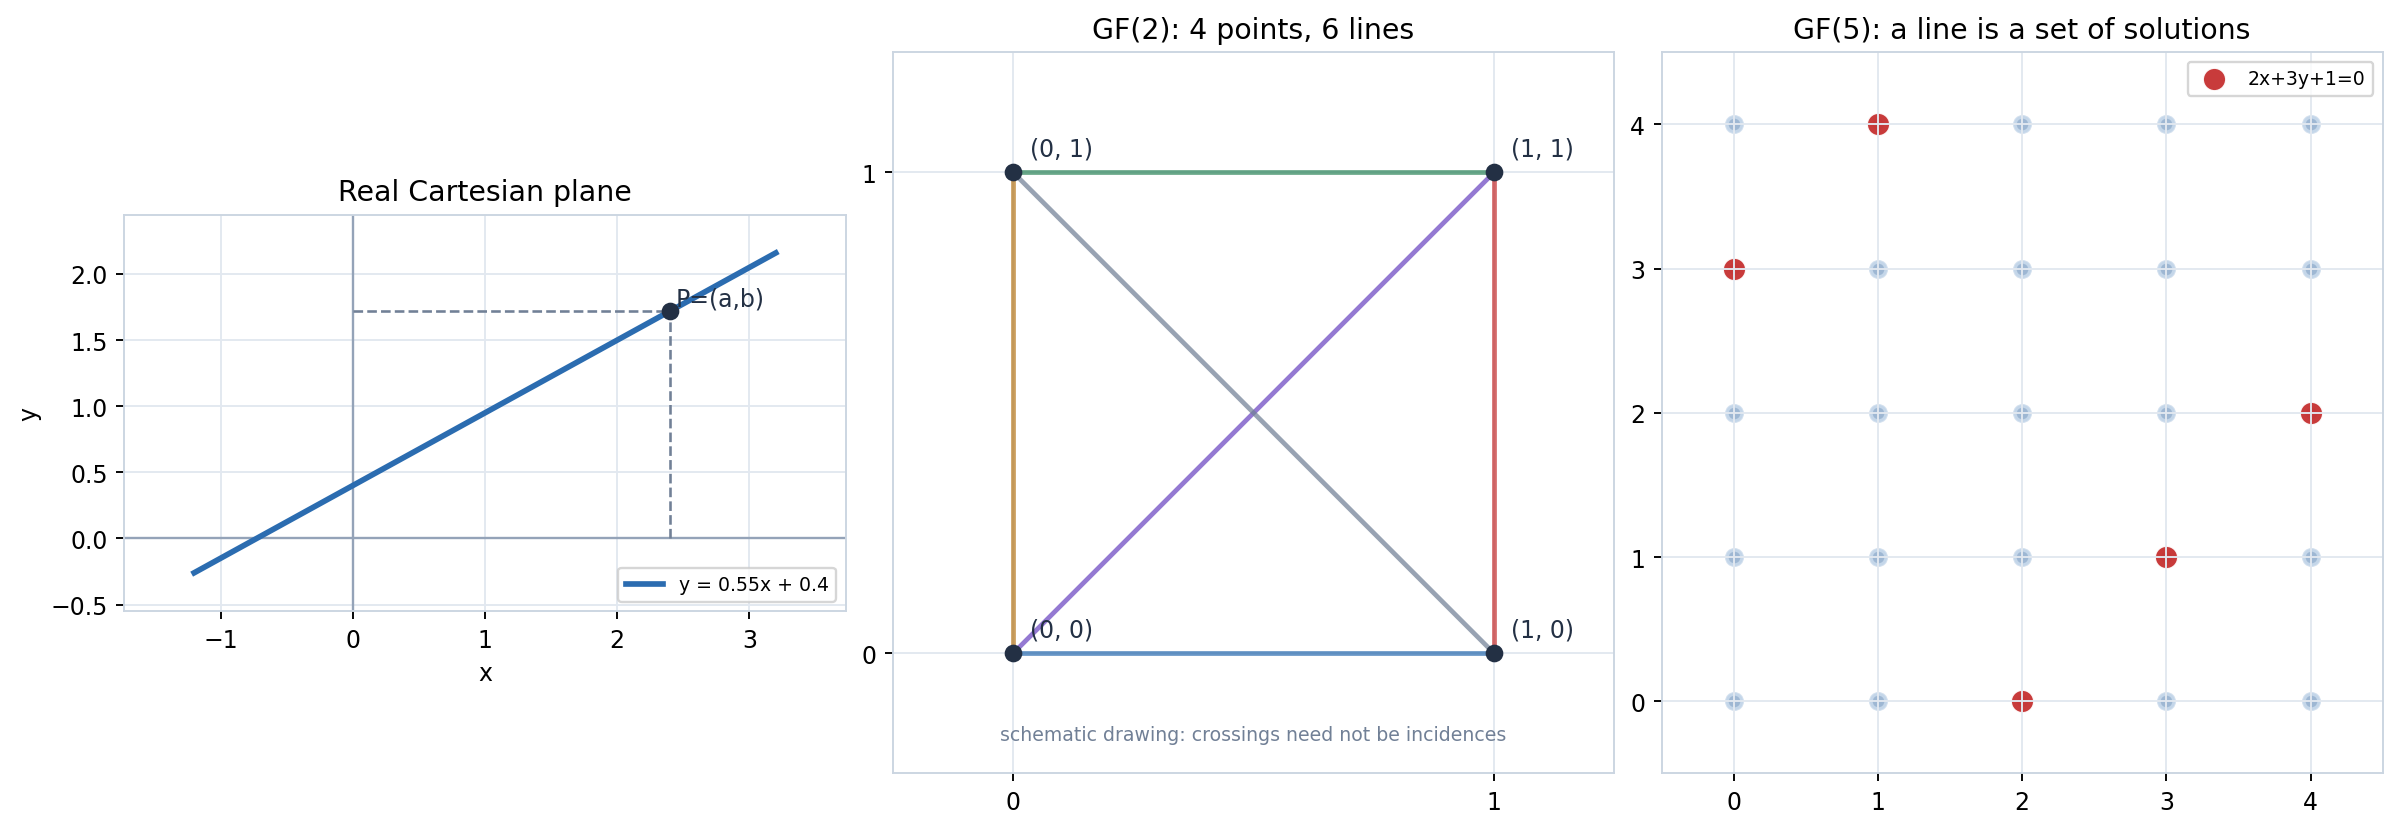

In [4]:
display_artifact(field_plane_path, width=960)
display_artifact(finite_html_path, width="100%", height=620)


## 2. Ordered fields and betweenness

Section 15 identifies the next dependency: a field by itself cannot define betweenness. To say that a point lies between two others, the coordinates must support a positive side and a negative side. That is the role of an ordered field. Once an order is present, a nonvertical line can use first coordinates, a vertical line can use second coordinates, and the usual betweenness axioms become inequalities in `F`.

The diagram below turns the Pasch-style axiom into a coordinate check. A vertical line enters a triangle through side `AB`. The third vertex `C` lies to one side of the vertical line, so the same line exits through exactly one of `AC` or `BC`. This is not a topological miracle in the coordinate model; it is an ordered-field statement about signs of endpoint differences.


In [5]:
def segment_parameter(P: np.ndarray, Q: np.ndarray, X: np.ndarray, tol: float = 1e-10) -> float | None:
    P = np.asarray(P, dtype=float)
    Q = np.asarray(Q, dtype=float)
    X = np.asarray(X, dtype=float)
    v = Q - P
    if np.linalg.norm(v) < tol:
        return None
    lam = float(((X - P) @ v) / (v @ v))
    if np.linalg.norm(P + lam * v - X) > 1e-8:
        return None
    return lam


def vertical_intersection(P: np.ndarray, Q: np.ndarray, x0: float) -> tuple[np.ndarray, float] | tuple[None, None]:
    P = np.asarray(P, dtype=float)
    Q = np.asarray(Q, dtype=float)
    if abs(Q[0] - P[0]) < 1e-12:
        return (None, None)
    lam = (x0 - P[0]) / (Q[0] - P[0])
    X = P + lam * (Q - P)
    return X, float(lam)


A = np.array([1.0, 4.0])
B = np.array([5.0, 2.0])
C = np.array([0.5, 0.55])
x0 = 3.0
sides = {"AB": (A, B), "AC": (A, C), "BC": (B, C)}
intersections = {}
for name, (P, Q) in sides.items():
    X, lam = vertical_intersection(P, Q, x0)
    intersections[name] = {
        "lambda": None if lam is None else lam,
        "point": None if X is None else [float(X[0]), float(X[1])],
        "between": bool(lam is not None and 0 < lam < 1),
    }

fig, ax = plt.subplots(figsize=(7.2, 5.6), constrained_layout=True)
triangle = np.vstack([A, B, C, A])
ax.plot(triangle[:, 0], triangle[:, 1], color=PALETTE["ink"], linewidth=2.1)
for point, label in [(A, "A"), (B, "B"), (C, "C")]:
    label_point(ax, point, label)
ax.axvline(x0, color=PALETTE["red"], linewidth=2.2, label="line l: x=d")
for name, data in intersections.items():
    if data["between"]:
        X = np.array(data["point"])
        ax.scatter([X[0]], [X[1]], s=130, color=PALETTE["red"], edgecolor="white", zorder=5)
        ax.text(X[0] + 0.08, X[1] + 0.08, f"l meets {name}", color=PALETTE["red"], fontsize=9)
    elif data["point"] is not None:
        X = np.array(data["point"])
        ax.scatter([X[0]], [X[1]], s=75, facecolor="white", edgecolor=PALETTE["gray"], zorder=4)
        ax.text(X[0] + 0.08, X[1] - 0.18, f"outside {name}", color=PALETTE["gray"], fontsize=8)
ax.set_title("Betweenness as ordered-field inequality")
ax.set_xlabel("x-coordinate in an ordered field")
ax.set_ylabel("y")
ax.legend(loc="upper right")
set_equal_axes(ax, margin=0.12)
ordered_path = save_matplotlib(fig, UNIT, "figures", "ordered-betweenness-pasch.png", root=ARTIFACT_ROOT, dpi=170)
plt.close(fig)

ordered_checks = {
    "line": "x = 3",
    "triangle_points": {"A": A.tolist(), "B": B.tolist(), "C": C.tolist()},
    "intersections": intersections,
    "pasch_crossed_sides": [name for name, data in intersections.items() if data["between"]],
    "pasch_exactly_two_side_hits": sum(data["between"] for data in intersections.values()) == 2,
    "third_vertex_side_test": {
        "A_x_minus_d": float(A[0] - x0),
        "B_x_minus_d": float(B[0] - x0),
        "C_x_minus_d": float(C[0] - x0),
    },
}
assert ordered_checks["pasch_crossed_sides"] == ["AB", "BC"]
ordered_check_path = save_json(ordered_checks, UNIT, "checks", "ordered-betweenness-checks.json", root=ARTIFACT_ROOT)
ordered_table_path = TABLE_DIR / "ordered-betweenness-pasch.csv"
pd.DataFrame([{"side": name, **data} for name, data in intersections.items()]).to_csv(ordered_table_path, index=False)

ordered_checks


{'line': 'x = 3',
 'triangle_points': {'A': [1.0, 4.0], 'B': [5.0, 2.0], 'C': [0.5, 0.55]},
 'intersections': {'AB': {'lambda': 0.5, 'point': [3.0, 3.0], 'between': True},
  'AC': {'lambda': -4.0, 'point': [3.0, 17.8], 'between': False},
  'BC': {'lambda': 0.4444444444444444,
   'point': [3.0, 1.3555555555555556],
   'between': True}},
 'pasch_crossed_sides': ['AB', 'BC'],
 'pasch_exactly_two_side_hits': True,
 'third_vertex_side_test': {'A_x_minus_d': -2.0,
  'B_x_minus_d': 2.0,
  'C_x_minus_d': -2.5}}

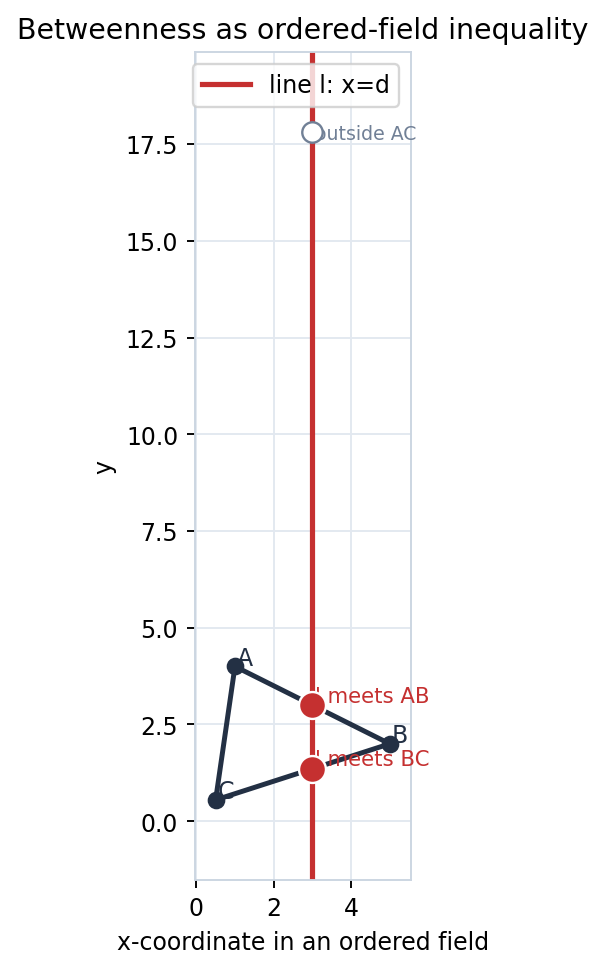

In [6]:
display_artifact(ordered_path, width=760)


## 3. Congruence and the square-root gates

Section 16 keeps congruence as algebraic as possible. Segment congruence is defined by equality of squared distance, so the field does not immediately need square roots. This is why the comparison `AB congruent CD` can be checked inside many fields.

The stronger operation of laying off a segment on a chosen ray is different. If the segment from `(0,0)` to `(1,1)` is to be copied onto the rational `x`-axis, the endpoint would need coordinate `sqrt(2)`, which is not rational. This is the first square-root gate. The Pythagorean condition asks for square roots of `1+a^2`; the Euclidean condition asks for square roots of every positive element and is equivalent, in this coordinate setting, to the familiar line-circle and circle-circle intersection properties.


In [7]:
x = sp.symbols("x")
sqrt2_roots = sp.solve(sp.Eq(x**2, 2), x)
rational_root_for_2 = any(root.is_rational for root in sqrt2_roots)
pythagorean_samples = {str(a): sp.sqrt(1 + sp.Rational(a) ** 2).is_rational for a in range(0, 6)}

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), constrained_layout=True)

ax = axes[0]
O = np.array([0.0, 0.0])
D = np.array([1.0, 1.0])
axis_end = np.array([math.sqrt(2), 0.0])
draw_segment(ax, O, D, color=PALETTE["blue"], linewidth=2.5, label="segment with dist^2 = 2")
draw_segment(ax, O, axis_end, color=PALETTE["red"], linewidth=2.5, linestyle="--", label="copy would end at sqrt(2)")
label_point(ax, O, "(0,0)")
label_point(ax, D, "(1,1)")
label_point(ax, axis_end, "(sqrt(2),0)", offset=(0.04, -0.14))
for n in range(3):
    ax.scatter([n], [0], s=38, color="#94a3b8")
ax.set_title("Distance squared is rational; the length need not be")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend(loc="upper left", fontsize=8)
set_equal_axes(ax, margin=0.16)

ax = axes[1]
rows = [
    ("compare segments", "dist^2(A,B)=dist^2(C,D)", "field arithmetic"),
    ("lay off a segment", "sqrt(1+a^2) in F", "Pythagorean field"),
    ("intersect circles", "sqrt(d) for every d>0", "Euclidean field"),
]
ypos = np.arange(len(rows))[::-1]
for yval, (name, formula, gate) in zip(ypos, rows):
    ax.scatter([0], [yval], s=220, color=PALETTE["blue"] if yval == 2 else PALETTE["gold"] if yval == 1 else PALETTE["green"])
    ax.text(0.18, yval + 0.10, name, fontsize=11, color=PALETTE["ink"], weight="bold")
    ax.text(0.18, yval - 0.08, formula, fontsize=10, color=PALETTE["ink"])
    ax.text(3.1, yval, gate, fontsize=10, color=PALETTE["red"] if yval < 2 else PALETTE["gray"], va="center")
for yval in ypos[:-1]:
    ax.annotate("", xy=(0, yval - 0.62), xytext=(0, yval - 0.18), arrowprops=dict(arrowstyle="->", color=PALETTE["gray"]))
ax.set_xlim(-0.35, 5.3)
ax.set_ylim(-0.8, 2.8)
ax.axis("off")
ax.set_title("Congruence properties ask for stronger algebra")

congruence_gate_path = save_matplotlib(fig, UNIT, "figures", "congruence-square-root-gate.png", root=ARTIFACT_ROOT, dpi=170)
plt.close(fig)

congruence_gate_checks = {
    "equation": "x^2 = 2",
    "roots": [str(root) for root in sqrt2_roots],
    "rational_root_for_2": bool(rational_root_for_2),
    "Q_pythagorean_sample_sqrt_1_plus_a_squared_is_rational": pythagorean_samples,
    "Q_fails_pythagorean_at_a_1": pythagorean_samples["1"] is False,
    "distance_squared_diagonal": 2,
}
assert not congruence_gate_checks["rational_root_for_2"]
assert congruence_gate_checks["Q_fails_pythagorean_at_a_1"]
congruence_gate_check_path = save_json(congruence_gate_checks, UNIT, "checks", "congruence-square-root-gate-checks.json", root=ARTIFACT_ROOT)
congruence_gate_checks


C:\Users\rahul\AppData\Local\Temp\ipykernel_25388\1880579771.py:22: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="upper left", fontsize=8)


{'equation': 'x^2 = 2',
 'roots': ['-sqrt(2)', 'sqrt(2)'],
 'rational_root_for_2': False,
 'Q_pythagorean_sample_sqrt_1_plus_a_squared_is_rational': {'0': True,
  '1': False,
  '2': False,
  '3': False,
  '4': False,
  '5': False},
 'Q_fails_pythagorean_at_a_1': True,
 'distance_squared_diagonal': 2}

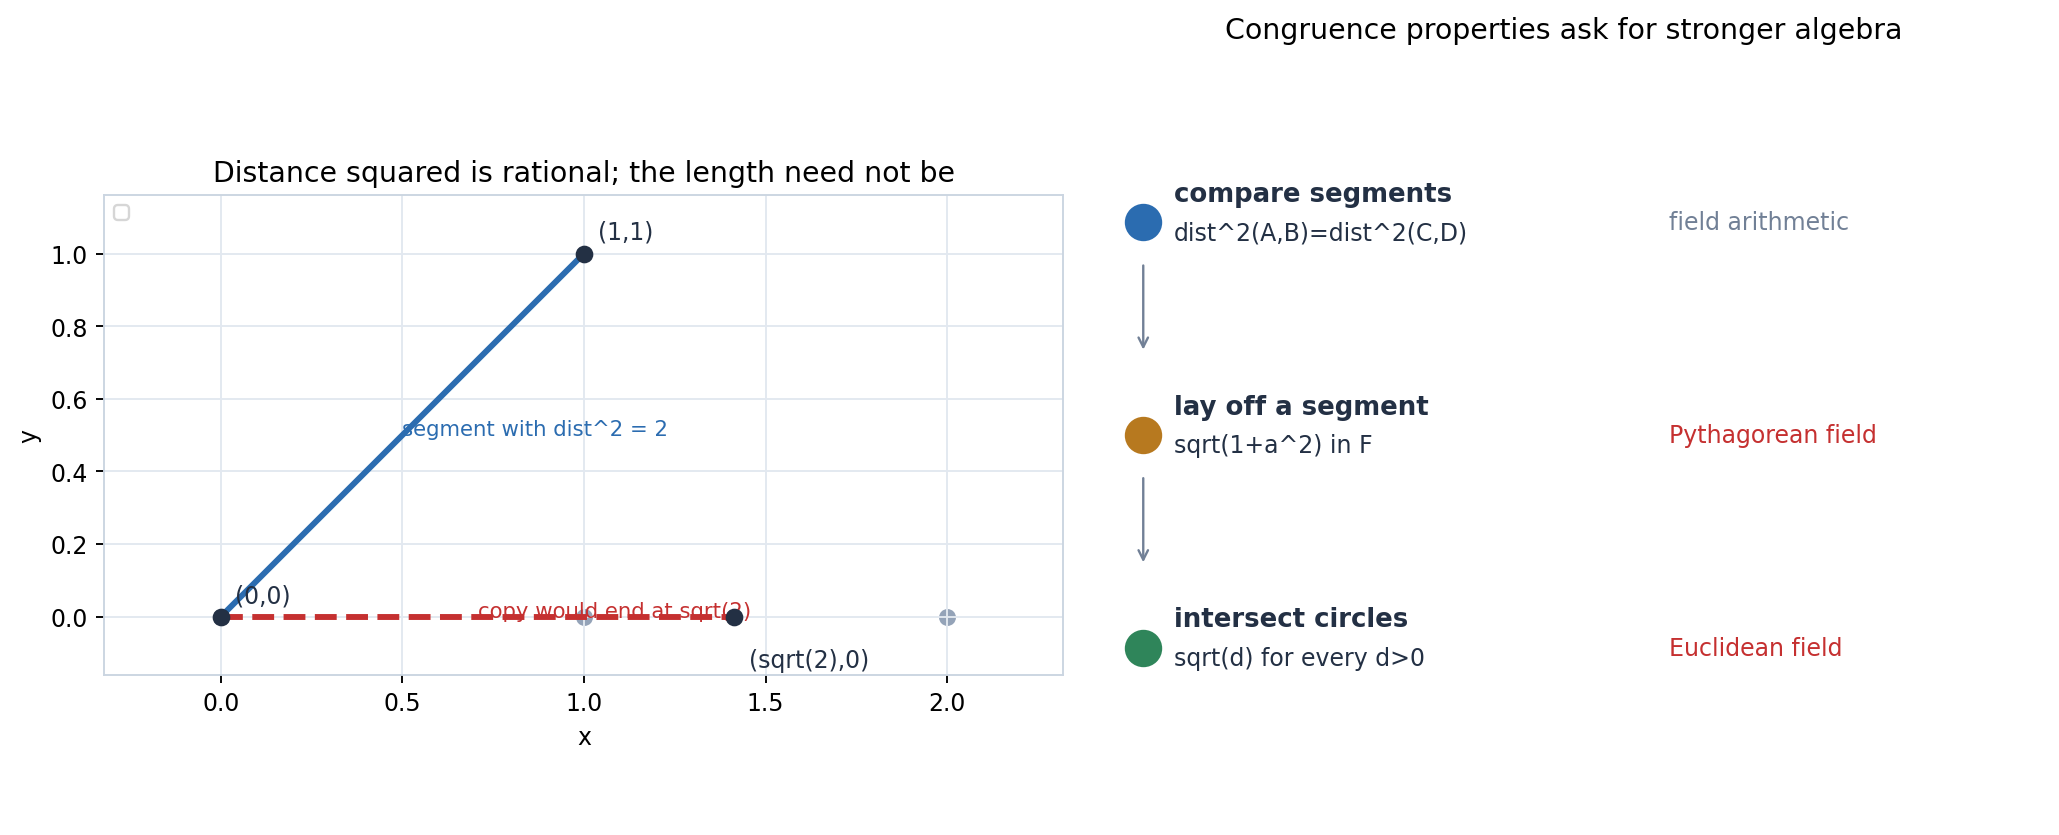

In [8]:
display_artifact(congruence_gate_path, width=900)


## 4. Rigid motions and SAS

Section 17 reframes Euclid's method of superposition. Moving a triangle onto another triangle is not a primitive permission; it becomes a theorem once there are enough rigid motions. In coordinates, the useful rigid motions are visible: translations move the origin, rotations with matrix `[[c, -s], [s, c]]` preserve distance when `c^2+s^2=1`, and reflections interchange the two sides of a line.

The next figure uses a rational rotation with `(c,s)=(3/5,4/5)`, then adds a translation. That pair is intentionally chosen because it belongs to a Pythagorean ordered field. The checks record that side lengths, the included angle, and the remaining triangle data are preserved. The dependency graph beside it shows how the chapter route proves SAS by first making rigid motions legitimate.


In [9]:
A = np.array([0.0, 0.0])
B = np.array([2.8, 0.4])
C = np.array([0.9, 2.2])
triangle = np.vstack([A, B, C])
c, s = 3 / 5, 4 / 5
R = np.array([[c, -s], [s, c]])
translation = np.array([2.6, -0.3])
transformed = triangle @ R.T + translation
reflected = triangle * np.array([1.0, -1.0])

original_sides = triangle_side_squares(triangle)
transformed_sides = triangle_side_squares(transformed)
side_residual = float(np.max(np.abs(original_sides - transformed_sides)))
angle_original = angle_tangent_from_vectors(B - A, C - A)
angle_transformed = angle_tangent_from_vectors(transformed[1] - transformed[0], transformed[2] - transformed[0])
angle_residual = abs(angle_original - angle_transformed)
reflection_sides = triangle_side_squares(reflected)
reflection_residual = float(np.max(np.abs(original_sides - reflection_sides)))

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.4), constrained_layout=True)
ax = axes[0]
for pts, color, label, marker in [
    (triangle, PALETTE["blue"], "original triangle", "o"),
    (transformed, PALETTE["red"], "rotation + translation", "s"),
]:
    closed = np.vstack([pts, pts[0]])
    ax.plot(closed[:, 0], closed[:, 1], color=color, linewidth=2.2, label=label)
    ax.scatter(pts[:, 0], pts[:, 1], s=70, color=color, marker=marker, edgecolor="white", zorder=5)
for point, label in zip(triangle, ["A", "B", "C"]):
    ax.text(point[0] + 0.05, point[1] + 0.07, label, color=PALETTE["blue"], fontsize=10)
for point, label in zip(transformed, ["A'", "B'", "C'"]):
    ax.text(point[0] + 0.05, point[1] + 0.07, label, color=PALETTE["red"], fontsize=10)
ax.arrow(A[0], A[1], translation[0], translation[1], length_includes_head=True, head_width=0.08, color=PALETTE["gray"], linestyle="--", alpha=0.55)
ax.set_title("Rigid motion preserves SAS data")
ax.legend(loc="upper left", fontsize=9)
set_equal_axes(ax, margin=0.14)

G = nx.DiGraph()
edges = [
    ("field F", "Cartesian plane F^2"),
    ("Cartesian plane F^2", "incidence + parallels"),
    ("ordered field", "betweenness"),
    ("betweenness", "rays and sides"),
    ("Pythagorean property", "segment transfer C1"),
    ("Pythagorean property", "rotations"),
    ("translations", "ERM"),
    ("rotations", "ERM"),
    ("reflections", "ERM"),
    ("ERM", "SAS C6"),
    ("Euclidean property", "circle intersections"),
    ("non-Arch ordered field", "A fails"),
]
G.add_edges_from(edges)
pos = {
    "field F": (0, 3), "Cartesian plane F^2": (1.6, 3), "incidence + parallels": (3.5, 3),
    "ordered field": (0, 2), "betweenness": (1.6, 2), "rays and sides": (3.5, 2),
    "Pythagorean property": (0, 1), "segment transfer C1": (1.6, 1.2), "rotations": (1.6, 0.75),
    "translations": (1.6, 0.2), "reflections": (1.6, -0.35), "ERM": (3.3, 0.2), "SAS C6": (4.8, 0.2),
    "Euclidean property": (0, -1.1), "circle intersections": (1.9, -1.1),
    "non-Arch ordered field": (0, -2.0), "A fails": (1.9, -2.0),
}
node_colors = [PALETTE["red"] if node in {"SAS C6", "A fails"} else PALETTE["blue"] if "property" in node or "ordered" in node else "#dbeafe" for node in G.nodes]
nx.draw_networkx_edges(G, pos, ax=axes[1], arrows=True, arrowstyle="-|>", arrowsize=12, edge_color="#64748b", width=1.4)
nx.draw_networkx_nodes(G, pos, ax=axes[1], node_color=node_colors, node_size=1450, edgecolors="white", linewidths=1.1)
nx.draw_networkx_labels(G, pos, ax=axes[1], font_size=8)
axes[1].set_title("Proof dependency scaffold")
axes[1].axis("off")

rigid_motion_path = save_matplotlib(fig, UNIT, "figures", "rigid-motion-sas-check.png", root=ARTIFACT_ROOT, dpi=170)
plt.close(fig)

fig, ax = plt.subplots(figsize=(9.5, 5.4), constrained_layout=True)
nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, arrowstyle="-|>", arrowsize=12, edge_color="#64748b", width=1.5)
nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, node_size=1700, edgecolors="white", linewidths=1.2)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=8)
ax.set_title("Chapter 3 axiom dependency route")
ax.axis("off")
dependency_path = save_matplotlib(fig, UNIT, "figures", "axiom-dependency-route.png", root=ARTIFACT_ROOT, dpi=170)
plt.close(fig)

rigid_checks = {
    "rotation_parameters": {"c": c, "s": s, "c_squared_plus_s_squared": c * c + s * s},
    "rotation_determinant": float(np.linalg.det(R)),
    "translation": translation.tolist(),
    "original_side_squares": original_sides.tolist(),
    "transformed_side_squares": transformed_sides.tolist(),
    "max_side_square_residual": side_residual,
    "included_angle_tangent_original": angle_original,
    "included_angle_tangent_transformed": angle_transformed,
    "included_angle_tangent_residual": angle_residual,
    "reflection_side_square_residual": reflection_residual,
    "dependency_graph": {"nodes": list(G.nodes), "edges": [list(edge) for edge in G.edges]},
}
assert abs(rigid_checks["rotation_parameters"]["c_squared_plus_s_squared"] - 1.0) < 1e-12
assert rigid_checks["max_side_square_residual"] < 1e-12
assert rigid_checks["included_angle_tangent_residual"] < 1e-12
rigid_check_path = save_json(rigid_checks, UNIT, "checks", "congruence-rigid-motion-checks.json", root=ARTIFACT_ROOT)
rigid_checks


{'rotation_parameters': {'c': 0.6, 's': 0.8, 'c_squared_plus_s_squared': 1.0},
 'rotation_determinant': 1.0,
 'translation': [2.6, -0.3],
 'original_side_squares': [7.999999999999999, 5.65, 6.850000000000001],
 'transformed_side_squares': [8.0, 5.65, 6.8500000000000005],
 'max_side_square_residual': 8.881784197001252e-16,
 'included_angle_tangent_original': 1.7058823529411762,
 'included_angle_tangent_transformed': 1.7058823529411768,
 'included_angle_tangent_residual': 6.661338147750939e-16,
 'reflection_side_square_residual': 0.0,
 'dependency_graph': {'nodes': ['field F',
   'Cartesian plane F^2',
   'incidence + parallels',
   'ordered field',
   'betweenness',
   'rays and sides',
   'Pythagorean property',
   'segment transfer C1',
   'rotations',
   'translations',
   'ERM',
   'reflections',
   'SAS C6',
   'Euclidean property',
   'circle intersections',
   'non-Arch ordered field',
   'A fails'],
  'edges': [['field F', 'Cartesian plane F^2'],
   ['Cartesian plane F^2', 'inci

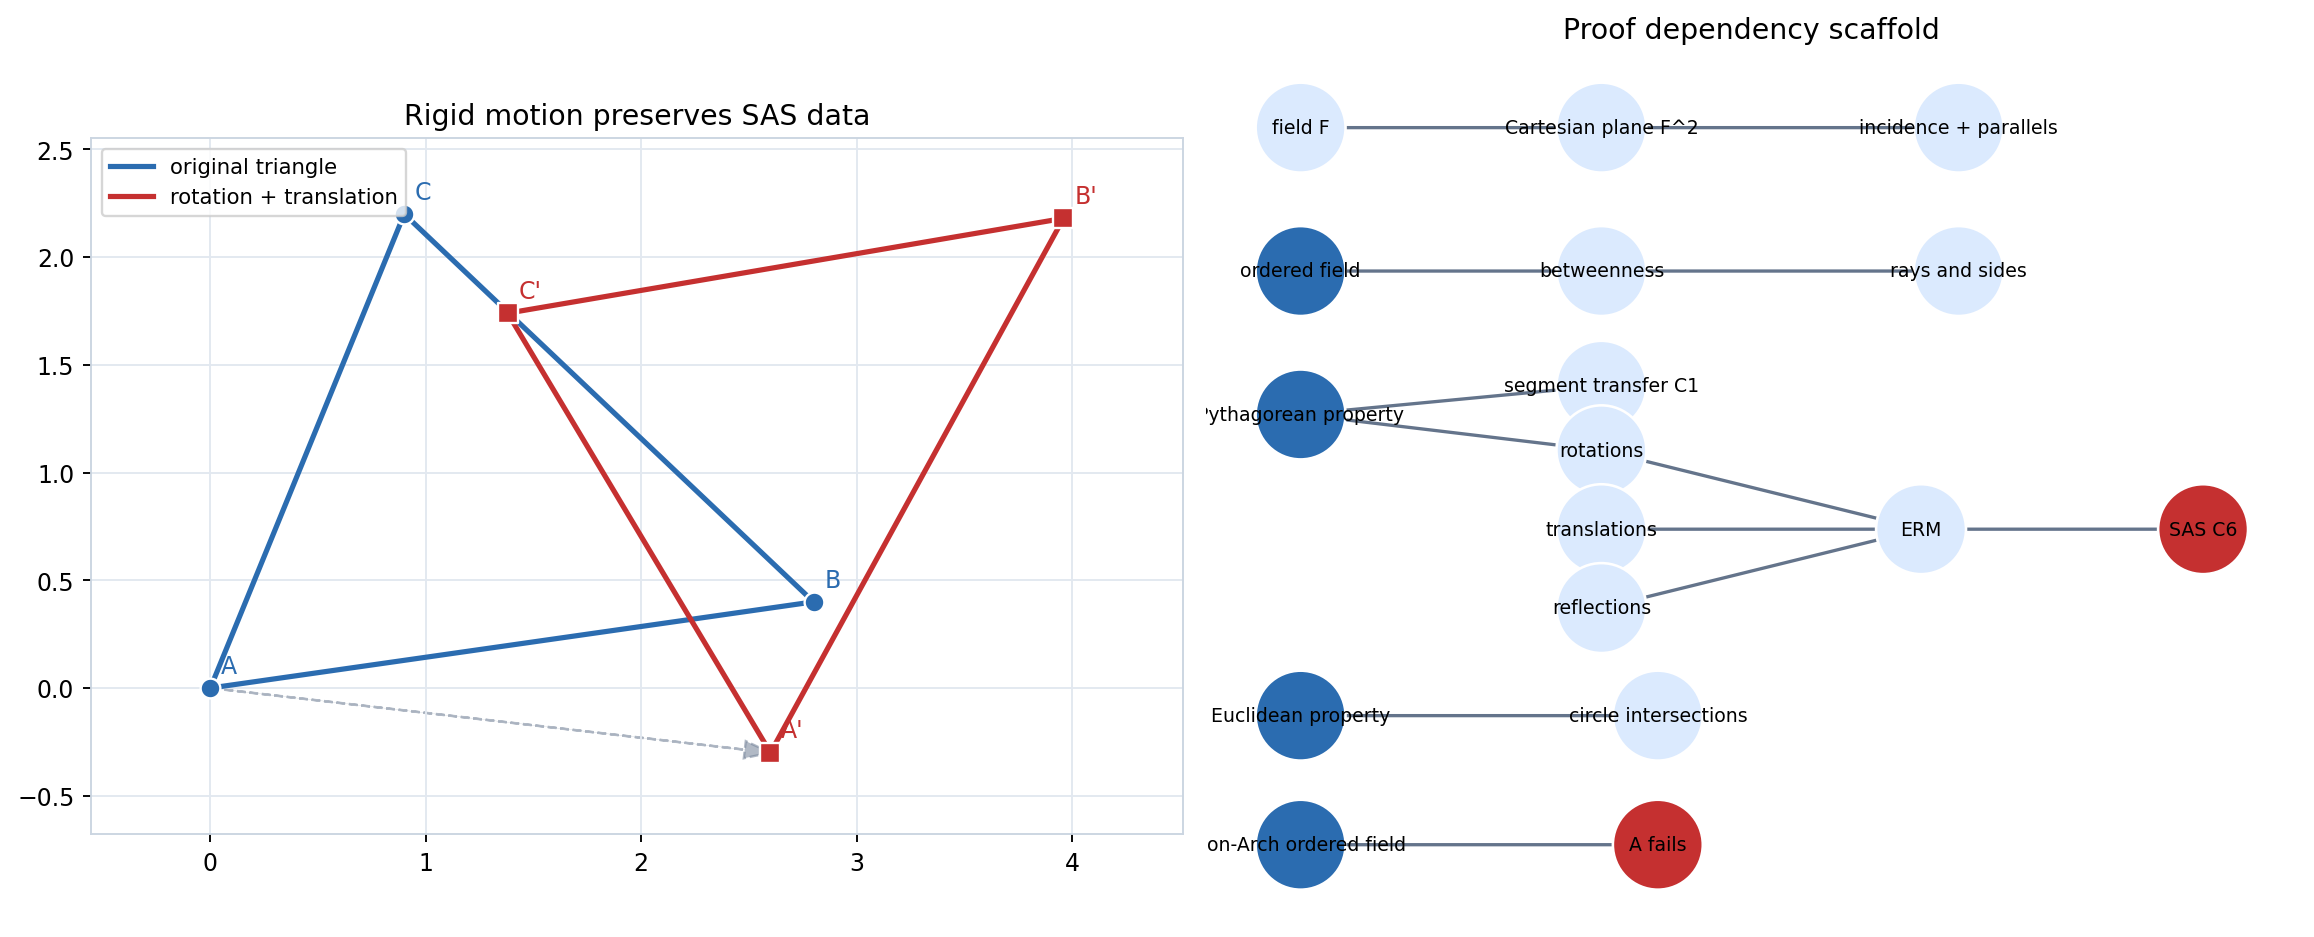

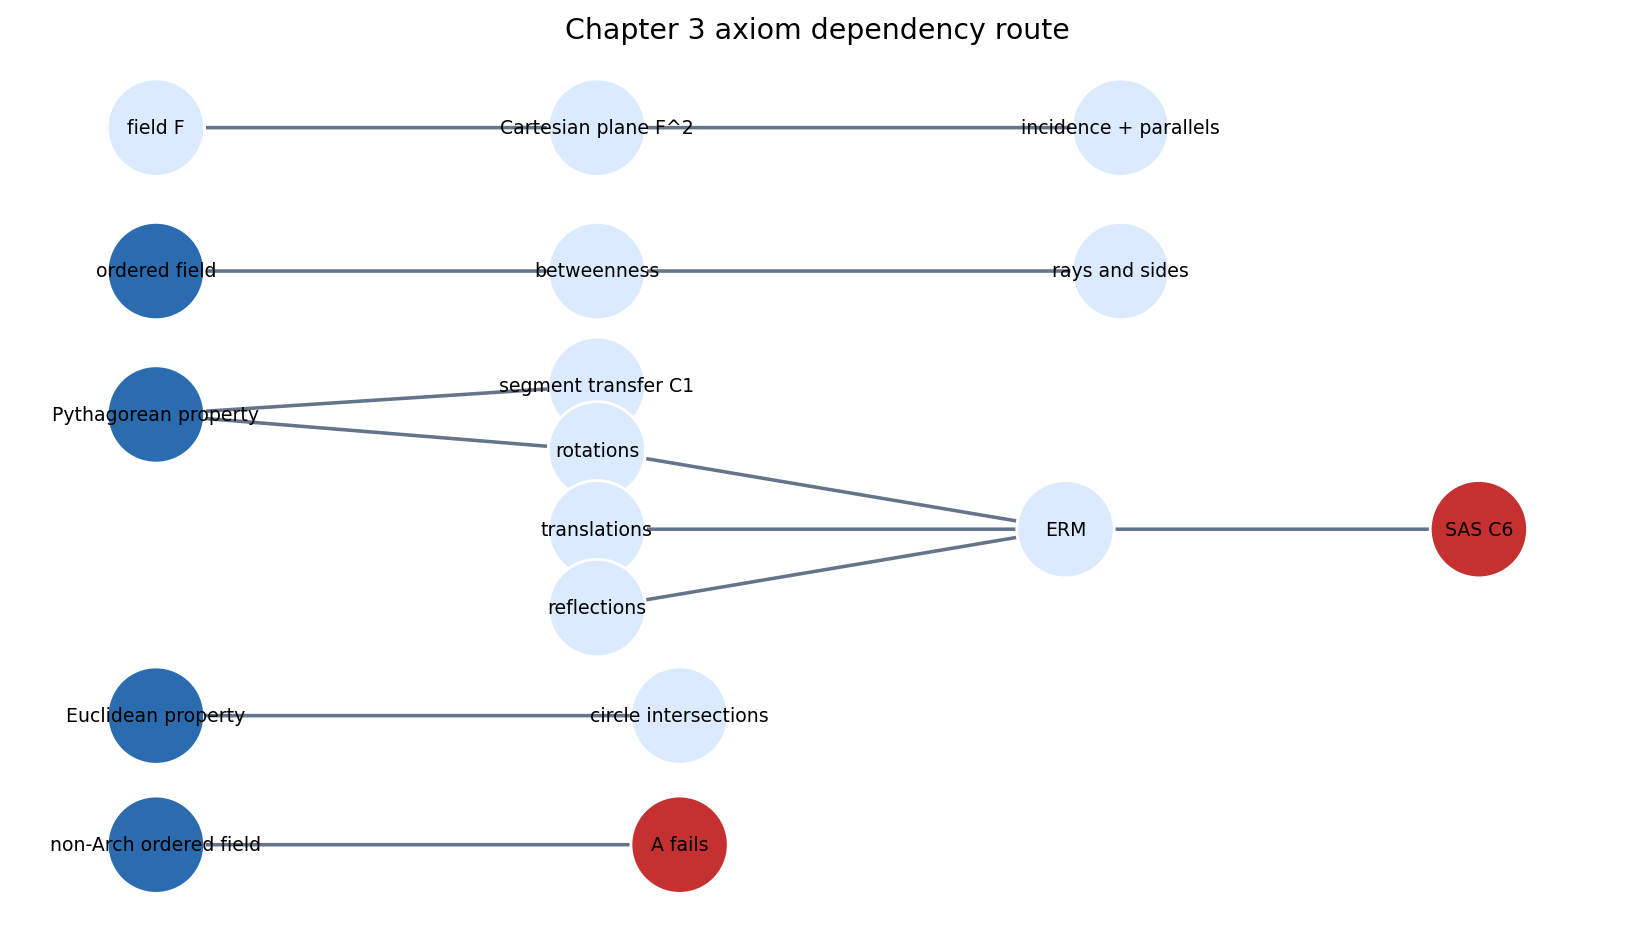

In [10]:
display_artifact(rigid_motion_path, width=960)
display_artifact(dependency_path, width=860)


## 5. Non-Archimedean and finite toy models

Finite fields and non-Archimedean fields fail different expectations. A finite field plane is excellent for incidence and parallelism, but cannot support order and betweenness. A non-Archimedean ordered field supports order, but breaks the Archimedean principle: there are elements larger than every integer and infinitesimals smaller than every positive reciprocal integer.

The source example orders rational functions by eventual sign for large real `t`. In that order, `t-n` is eventually positive for every integer `n`, so `t` is infinite. Likewise, `1/n - 1/t` is eventually positive for every positive `n`, so `1/t` is infinitesimal. The plot is a scale ladder, not a real number line; its point is to separate finite, infinite, and infinitesimal behavior by degree growth.


In [11]:
t = sp.symbols("t")


def eventual_sign(expr: sp.Expr) -> int:
    num, den = sp.fraction(sp.together(expr))
    num_poly = sp.Poly(num, t)
    den_poly = sp.Poly(den, t)
    if num_poly.is_zero:
        return 0
    lead_num = sp.Rational(num_poly.LC())
    lead_den = sp.Rational(den_poly.LC())
    value = lead_num / lead_den
    return 1 if value > 0 else -1


def eventually_greater(a: sp.Expr, b: sp.Expr) -> bool:
    return eventual_sign(a - b) > 0


nonarch_checks = {
    "t_greater_than_tested_integers": {str(n): eventually_greater(t, sp.Integer(n)) for n in range(1, 13)},
    "one_over_t_positive": eventual_sign(1 / t) > 0,
    "one_over_t_less_than_reciprocals": {f"1/{n}": eventually_greater(sp.Rational(1, n), 1 / t) for n in range(1, 13)},
    "order_chain_sample": ["0", "1/t", "1", "2", "...", "t", "t+1", "t^2"],
    "finite_field_order_failure": "GF(p) cannot be ordered because ordered fields have characteristic 0, while GF(p) has characteristic p.",
}
assert all(nonarch_checks["t_greater_than_tested_integers"].values())
assert nonarch_checks["one_over_t_positive"]
assert all(nonarch_checks["one_over_t_less_than_reciprocals"].values())

ladder_items = [
    ("1/t", -1.0, "infinitesimal"),
    ("1", 0.0, "finite"),
    ("2", 0.08, "finite"),
    ("12", 0.25, "finite tested integer"),
    ("t", 1.0, "infinite"),
    ("t+1", 1.08, "same growth as t"),
    ("t^2", 2.0, "larger infinite"),
]
fig, ax = plt.subplots(figsize=(9.5, 3.9), constrained_layout=True)
ax.axhline(0, color="#94a3b8", linewidth=1.0)
for label, xpos, kind in ladder_items:
    color = PALETTE["red"] if "infinite" in kind else PALETTE["green"] if kind == "infinitesimal" else PALETTE["blue"]
    ax.scatter([xpos], [0], s=180, color=color, edgecolor="white", zorder=4)
    ax.text(xpos, 0.11 if xpos < 1.5 else -0.18, label, ha="center", fontsize=10, color=PALETTE["ink"])
    ax.text(xpos, -0.18 if xpos < 1.5 else 0.11, kind, ha="center", fontsize=8, color=color)
for n in range(1, 7):
    ax.annotate("", xy=(0.95, 0.02 + n * 0.005), xytext=(0.35 + 0.04 * n, 0.02 + n * 0.005), arrowprops=dict(arrowstyle="->", color="#cbd5e1", linewidth=0.8))
ax.text(0.62, 0.22, "every tested integer stays left of t", ha="center", fontsize=9, color=PALETTE["gray"])
ax.set_xlim(-1.35, 2.35)
ax.set_ylim(-0.42, 0.44)
ax.set_yticks([])
ax.set_xlabel("growth rank in the eventual-order toy model")
ax.set_title("Non-Archimedean scale: finite, infinitesimal, and infinite elements")
for spine in ["left", "right", "top"]:
    ax.spines[spine].set_visible(False)
nonarch_path = save_matplotlib(fig, UNIT, "figures", "nonarchimedean-scale-ladder.png", root=ARTIFACT_ROOT, dpi=170)
plt.close(fig)

comparison_rows = []
for n in range(1, 13):
    comparison_rows.append({"comparison": f"t > {n}", "eventual_sign_left_minus_right": eventual_sign(t - n), "true": eventually_greater(t, n)})
    comparison_rows.append({"comparison": f"1/t < 1/{n}", "eventual_sign_left_minus_right": eventual_sign(sp.Rational(1, n) - 1 / t), "true": eventually_greater(sp.Rational(1, n), 1 / t)})
nonarch_table_path = TABLE_DIR / "nonarchimedean-scale-comparisons.csv"
pd.DataFrame(comparison_rows).to_csv(nonarch_table_path, index=False)
nonarch_check_path = save_json(nonarch_checks, UNIT, "checks", "nonarchimedean-checks.json", root=ARTIFACT_ROOT)
nonarch_checks


{'t_greater_than_tested_integers': {'1': True,
  '2': True,
  '3': True,
  '4': True,
  '5': True,
  '6': True,
  '7': True,
  '8': True,
  '9': True,
  '10': True,
  '11': True,
  '12': True},
 'one_over_t_positive': True,
 'one_over_t_less_than_reciprocals': {'1/1': True,
  '1/2': True,
  '1/3': True,
  '1/4': True,
  '1/5': True,
  '1/6': True,
  '1/7': True,
  '1/8': True,
  '1/9': True,
  '1/10': True,
  '1/11': True,
  '1/12': True},
 'order_chain_sample': ['0', '1/t', '1', '2', '...', 't', 't+1', 't^2'],
 'finite_field_order_failure': 'GF(p) cannot be ordered because ordered fields have characteristic 0, while GF(p) has characteristic p.'}

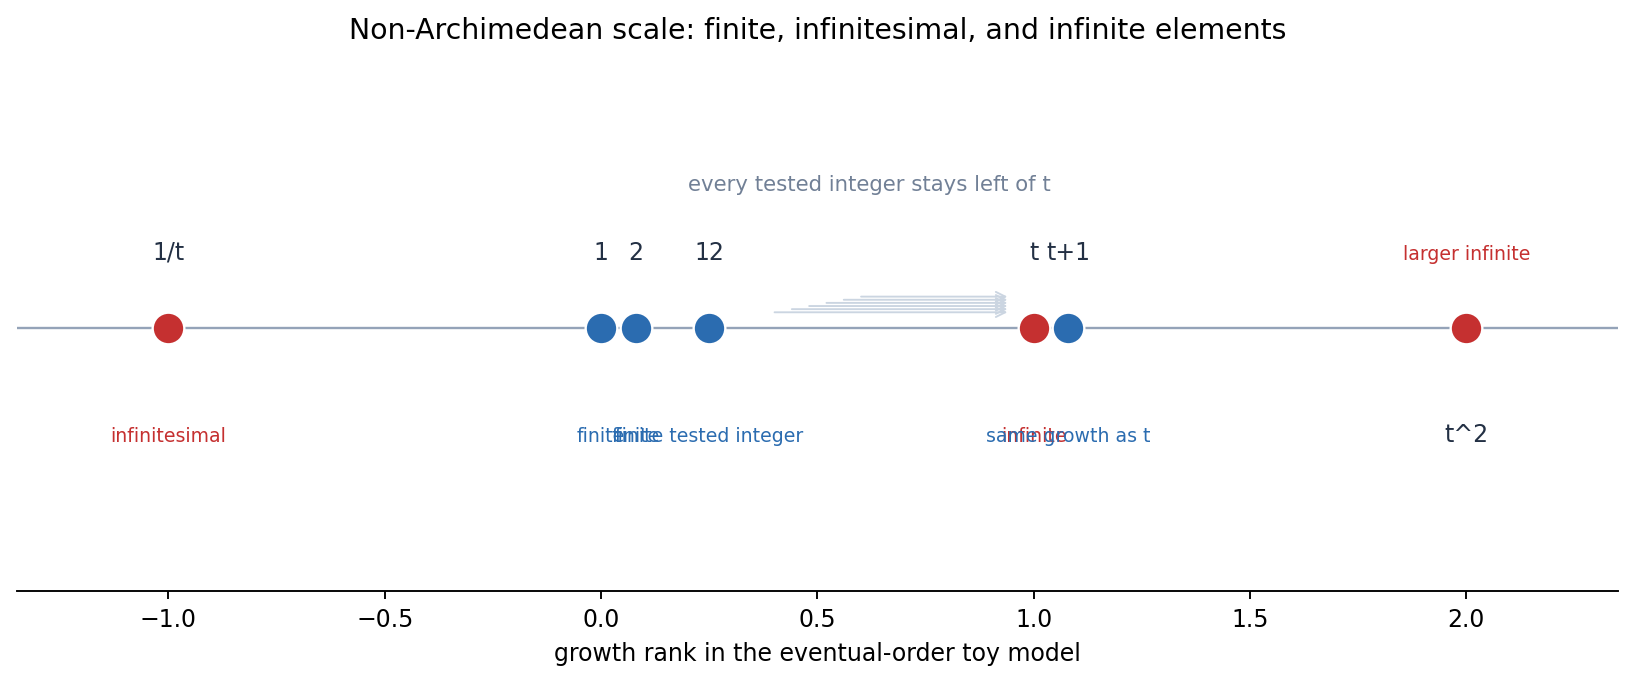

In [12]:
display_artifact(nonarch_path, width=860)


## Applied Lab: audit a coordinate geometry by its field

The lab question is practical: if someone hands you a field, what geometry can you responsibly claim to have built from it? The table below is deliberately conservative. Some entries are computed directly in this notebook, such as finite-field incidence and the rational failure at `sqrt(2)`. Others are theorem-routed summaries from the chapter: ordered fields provide betweenness, Pythagorean ordered fields provide enough rigid motions for SAS, and Euclidean fields provide circle intersections.

Use the table as a diagnostic checklist. Start with incidence. Ask whether an order exists. Ask whether the Pythagorean square-root condition holds. Ask whether every positive element has a square root. Finally ask whether Archimedes' axiom is valid or whether an element like `t` outruns all integers.


In [13]:
lab_rows = [
    {
        "model": "GF(5)",
        "field_plane": "finite prime field",
        "incidence_parallel": "yes: computed affine plane counts",
        "ordered_betweenness": "no: ordered fields have characteristic 0",
        "segment_transfer_C1": "no in this chapter route",
        "ERM_SAS": "no in this chapter route",
        "circle_intersections": "no order/Euclidean structure",
        "Archimedean": "not applicable as ordered field",
        "diagnostic": "excellent incidence toy; no between relation",
    },
    {
        "model": "Q",
        "field_plane": "rational coordinate plane",
        "incidence_parallel": "yes: field operations solve lines",
        "ordered_betweenness": "yes: usual order",
        "segment_transfer_C1": "fails: sqrt(2) not in Q",
        "ERM_SAS": "not enough for full Hilbert plane",
        "circle_intersections": "fails sample positive square root",
        "Archimedean": "yes",
        "diagnostic": "order is present but square-root gates fail",
    },
    {
        "model": "R",
        "field_plane": "real Cartesian plane",
        "incidence_parallel": "yes",
        "ordered_betweenness": "yes",
        "segment_transfer_C1": "yes",
        "ERM_SAS": "yes",
        "circle_intersections": "yes",
        "Archimedean": "yes and Dedekind complete",
        "diagnostic": "standard analytic Euclidean model",
    },
    {
        "model": "Hilbert field Omega",
        "field_plane": "smallest ordered Pythagorean field generated from Q",
        "incidence_parallel": "yes",
        "ordered_betweenness": "yes",
        "segment_transfer_C1": "yes by Pythagorean closure",
        "ERM_SAS": "yes by rigid-motion theorem route",
        "circle_intersections": "not forced by Pythagorean closure alone",
        "Archimedean": "yes as a subfield of R",
        "diagnostic": "minimal field for Hilbert betweenness/congruence route",
    },
    {
        "model": "R(t) with eventual order",
        "field_plane": "rational functions ordered at infinity",
        "incidence_parallel": "yes",
        "ordered_betweenness": "yes: eventual order",
        "segment_transfer_C1": "not guaranteed before closure",
        "ERM_SAS": "not guaranteed before closure",
        "circle_intersections": "not guaranteed before closure",
        "Archimedean": "no: t > n for every integer n",
        "diagnostic": "ordered but non-Archimedean",
    },
    {
        "model": "Omega' over R(t)",
        "field_plane": "Pythagorean closure toy from Section 18",
        "incidence_parallel": "yes",
        "ordered_betweenness": "yes",
        "segment_transfer_C1": "yes by construction",
        "ERM_SAS": "yes by Pythagorean ordered-field route",
        "circle_intersections": "not necessarily Euclidean",
        "Archimedean": "no",
        "diagnostic": "Hilbert-style plane without Archimedes' axiom",
    },
    {
        "model": "K' over R(t)",
        "field_plane": "Euclidean closure toy from Section 18",
        "incidence_parallel": "yes",
        "ordered_betweenness": "yes",
        "segment_transfer_C1": "yes",
        "ERM_SAS": "yes",
        "circle_intersections": "yes by Euclidean closure",
        "Archimedean": "no",
        "diagnostic": "Euclidean plane can still be non-Archimedean",
    },
]
lab_df = pd.DataFrame(lab_rows)
lab_path = TABLE_DIR / "applied-lab-model-audit.csv"
lab_df.to_csv(lab_path, index=False)
lab_check_path = save_json(
    {
        "rows": len(lab_rows),
        "models": [row["model"] for row in lab_rows],
        "computed_support": [
            "GF(5) incidence counts",
            "Q failure at sqrt(2)",
            "R(t) eventual-order comparisons",
            "rigid motion distance and angle preservation",
        ],
        "source_theorem_routing": [
            "ordered field -> betweenness",
            "Pythagorean ordered field -> C1/ERM/SAS route",
            "Euclidean field -> circle intersections",
            "non-Archimedean ordered field -> Archimedes axiom can fail",
        ],
    },
    UNIT,
    "checks",
    "applied-lab-model-audit-checks.json",
    root=ARTIFACT_ROOT,
)
lab_df


,model,field_plane,incidence_parallel,ordered_betweenness,segment_transfer_C1,ERM_SAS,circle_intersections,Archimedean,diagnostic
0,GF(5),finite prime field,yes: computed affine plane counts,no: ordered fields have characteristic 0,no in this chapter route,no in this chapter route,no order/Euclidean structure,not applicable as ordered field,excellent incidence toy; no between relation
1,Q,rational coordinate plane,yes: field operations solve lines,yes: usual order,fails: sqrt(2) not in Q,not enough for full Hilbert plane,fails sample positive square root,yes,order is present but square-root gates fail
2,R,real Cartesian plane,yes,yes,yes,yes,yes,yes and Dedekind complete,standard analytic Euclidean model
3,Hilbert field Omega,smallest ordered Pythagorean field generated f...,yes,yes,yes by Pythagorean closure,yes by rigid-motion theorem route,not forced by Pythagorean closure alone,yes as a subfield of R,minimal field for Hilbert betweenness/congruen...
4,R(t) with eventual order,rational functions ordered at infinity,yes,yes: eventual order,not guaranteed before closure,not guaranteed before closure,not guaranteed before closure,no: t > n for every integer n,ordered but non-Archimedean
5,Omega' over R(t),Pythagorean closure toy from Section 18,yes,yes,yes by construction,yes by Pythagorean ordered-field route,not necessarily Euclidean,no,Hilbert-style plane without Archimedes' axiom
6,K' over R(t),Euclidean closure toy from Section 18,yes,yes,yes,yes,yes by Euclidean closure,no,Euclidean plane can still be non-Archimedean


## Takeaways

- The coordinate plane over a field is already a strong incidence geometry: lines are linear equations, and parallelism is a slope condition.
- Betweenness is not coordinate syntax alone. It requires an order on the field.
- Congruence can start with distance squared, but actual segment transfer and circle intersections expose square-root requirements.
- Rigid motions make Euclid's superposition method into a structural theorem: enough translations, rotations, and reflections imply the SAS axiom.
- Finite fields and non-Archimedean fields are not side curiosities. They are diagnostic models showing exactly which axioms depend on order, square roots, and Archimedean behavior.


In [14]:
expected_artifacts = [
    field_plane_path,
    finite_html_path,
    ordered_path,
    congruence_gate_path,
    rigid_motion_path,
    dependency_path,
    nonarch_path,
    finite_summary_path,
    ordered_table_path,
    nonarch_table_path,
    lab_path,
    source_span_path,
    storyboard_path,
    finite_check_path,
    ordered_check_path,
    congruence_gate_check_path,
    rigid_check_path,
    nonarch_check_path,
    lab_check_path,
]
checked_artifacts = [assert_artifact(path, min_bytes=128) for path in expected_artifacts]

notebook_source = NOTEBOOK_PATH.read_text(encoding="utf-8")
forbidden_builder_token = "build_" + "unit_visuals"
assert forbidden_builder_token not in notebook_source
assert finite_checks["GF(5)"]["unique_line_through_two_points"]
assert ordered_checks["pasch_exactly_two_side_hits"]
assert congruence_gate_checks["Q_fails_pythagorean_at_a_1"]
assert rigid_checks["max_side_square_residual"] < 1e-12
assert rigid_checks["included_angle_tangent_residual"] < 1e-12
assert all(nonarch_checks["t_greater_than_tested_integers"].values())
assert all(nonarch_checks["one_over_t_less_than_reciprocals"].values())

final_sanity = {
    "unit": UNIT,
    "notebook": NOTEBOOK_PATH.relative_to(BOOK_ROOT).as_posix(),
    "source_span": SOURCE_SPAN,
    "artifact_count": len(checked_artifacts),
    "artifacts": [path.relative_to(BOOK_ROOT).as_posix() for path in checked_artifacts],
    "checks": {
        "no_visual_builder_call": True,
        "GF5_points": finite_checks["GF(5)"]["points"],
        "GF5_lines": finite_checks["GF(5)"]["lines"],
        "GF5_line_size": finite_checks["GF(5)"]["line_size_min"],
        "ordered_pasch_crossed_sides": ordered_checks["pasch_crossed_sides"],
        "Q_fails_pythagorean_at_a_1": congruence_gate_checks["Q_fails_pythagorean_at_a_1"],
        "rigid_motion_max_side_square_residual": rigid_checks["max_side_square_residual"],
        "rigid_motion_angle_tangent_residual": rigid_checks["included_angle_tangent_residual"],
        "nonarch_t_greater_than_1_to_12": all(nonarch_checks["t_greater_than_tested_integers"].values()),
        "nonarch_one_over_t_infinitesimal_sample": all(nonarch_checks["one_over_t_less_than_reciprocals"].values()),
        "applied_lab_rows": len(lab_df),
    },
    "libraries_used": {
        "matplotlib": "durable 2D field-plane, betweenness, congruence, rigid-motion, and non-Archimedean diagrams",
        "plotly": "interactive finite-field line explorer where changing slope changes the selected solution set",
        "sympy": "exact square-root and rational-function eventual-order checks",
        "networkx": "proof dependency scaffold from field assumptions to axiom families",
        "pandas": "model audit and invariant summary tables",
        "numpy": "linear algebra for rigid-motion and distance invariants",
    },
}
final_sanity_path = save_json(final_sanity, UNIT, "checks", "final_sanity.json", root=ARTIFACT_ROOT)
save_json(
    {
        "unit": UNIT,
        "artifact_count": final_sanity["artifact_count"],
        "visual_artifacts": [path.relative_to(BOOK_ROOT).as_posix() for path in checked_artifacts if path.suffix.lower() in {".png", ".html"}],
        "checks": final_sanity["checks"],
    },
    UNIT,
    "checks",
    "visual-checks.json",
    root=ARTIFACT_ROOT,
)
save_json(
    {
        "unit": UNIT,
        "notebook": final_sanity["notebook"],
        "source_span": "printed pp. 117-164 / PDF pp. 129-176",
        "artifact_count": final_sanity["artifact_count"],
        "no_visual_builder_call": True,
        "lab_rows": len(lab_df),
    },
    UNIT,
    "checks",
    "notebook-sanity.json",
    root=ARTIFACT_ROOT,
)

final_sanity


{'unit': 'chapter-03',
 'notebook': 'chapter-03-geometry-over-fields/03-geometry-over-fields.ipynb',
 'source_span': {'book': 'Geometry: Euclid and Beyond',
  'chapter': 3,
  'chapter_title': 'Geometry over Fields',
  'printed_pages': '117-164',
  'pdf_pages': '129-176',
  'sections': {'13': 'The Real Cartesian Plane',
   '14': 'Abstract Fields and Incidence',
   '15': 'Ordered Fields and Betweenness',
   '16': 'Congruence of Segments and Angles',
   '17': 'Rigid Motions and SAS',
   '18': 'Non-Archimedean Geometry'},
  'source_use': 'Rendered source pages were inspected for structure, terminology, and theorem route. Notebook prose, code, diagrams, checks, and labs are original.'},
 'artifact_count': 19,
 'artifacts': ['artifacts/chapter-03/figures/field-plane-comparison.png',
  'artifacts/chapter-03/interactive/finite-field-line-explorer.html',
  'artifacts/chapter-03/figures/ordered-betweenness-pasch.png',
  'artifacts/chapter-03/figures/congruence-square-root-gate.png',
  'artifacts